# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

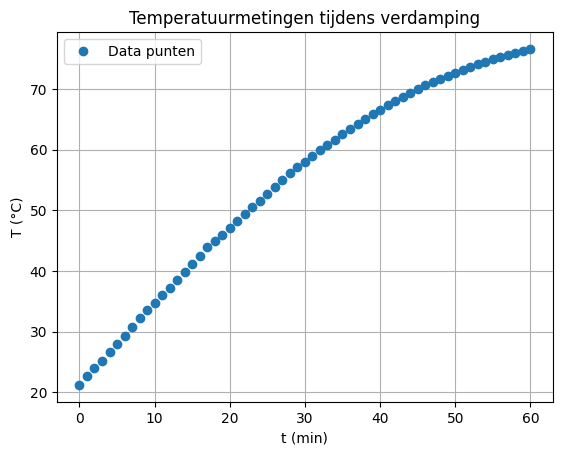

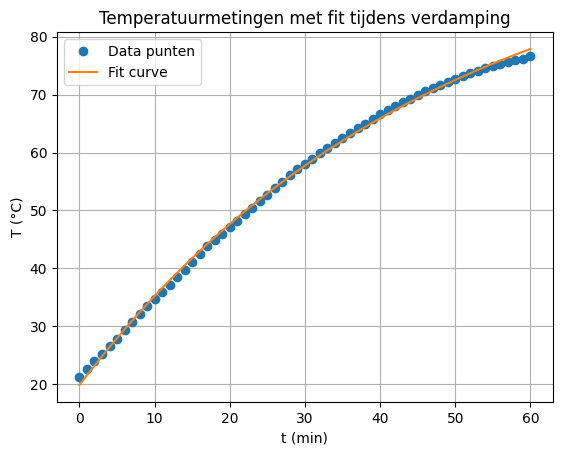

Fit parameters:
T0= 19.91 °C
T_max= 100.81 °C
k= 0.0210 1/min
Opgewarmde hoeveelheid water: 0.4721 kg
Verdampte hoeveelheid water: 0.0180 kg
Totale hoeveelheid warmte Q: 155155.18 J
Totaal benodigde energie Q: 155155.18 J
Totaal beschikbare energie E: 720000.00 J
Energieverlies: 78.45 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data= np.loadtxt("tempmetingen-verdamping.csv", delimiter=";", skiprows=1)

t= data[:,0]
T= data[:,1]

m_maatbeker= 0.8208 # kg
m_maatbeker_met_water_start= 1.2929 # kg
m_maatbeker_met_water_einde= 1.2749 # kg

m_water_begin= m_maatbeker_met_water_start - m_maatbeker
m_water_eind= m_maatbeker_met_water_einde - m_maatbeker
m_verdamping= m_water_begin - m_water_eind

plt.plot(t, T, "o", label="Data punten")
plt.xlabel("t (min)")
plt.ylabel("T (°C)")
plt.title("Temperatuurmetingen tijdens verdamping")
plt.legend()
plt.grid()
plt.show()

def f(t, T0, T_max, k):
    return T0 + (T_max - T0) * (1 - np.exp(-k * t))

popt, pcov= curve_fit(f, t, T, p0=[21, 100, 0.1])

T0, T_max, k= popt

T_fit= f(t, T0, T_max, k)

plt.plot(t, T, "o", label="Data punten")
plt.plot(t, T_fit, "-", label="Fit curve")
plt.xlabel("t (min)")
plt.ylabel("T (°C)")
plt.title("Temperatuurmetingen met fit tijdens verdamping")
plt.legend()
plt.grid()
plt.show()
print(f"Fit parameters:\nT0= {T0:.2f} °C\nT_max= {T_max:.2f} °C\nk= {k:.4f} 1/min")

#Aanname: specifieke warmtecapaciteit van water c_water= 4186 J/(kg * K)
c_water= 4186 # J/(kg * K)
L_v= 2256e3 # J/kg

Delta_T= T_fit[-1] - T_fit[0]
Q_opwarming= m_water_begin * c_water * Delta_T
Q_verdamping= m_verdamping * L_v
Q_totaal= Q_opwarming + Q_verdamping

print(f"Opgewarmde hoeveelheid water: {m_water_begin:.4f} kg")
print(f"Verdampte hoeveelheid water: {m_verdamping:.4f} kg")
print(f"Totale hoeveelheid warmte Q: {Q_totaal:.2f} J")

#Energie per tijdseenheid (vermogen) P

P= 200 # W
totaal_tijd= t[-1] * 60 # omzetten van minuten naar seconden

E= P * totaal_tijd 

verlies= 1- (Q_totaal / E)
print(f"Totaal benodigde energie Q: {Q_totaal:.2f} J")
print(f"Totaal beschikbare energie E: {E:.2f} J")
print(f"Energieverlies: {verlies*100:.2f} %")

# Conclusie: De berekende energie is lager dan de beschikbare energie. Dit wijst op energieverlies door warmteverlies aan de omgeving.









In [ ]:
#Aanbevelingen: 

# Gebruik een beter geïsoleerde container om warmteverlies te verminderen. 
# Meet de omgevingstemperatuur en houd deze constant tijdens het experiment. 
# Herhaal het experiment meerdere keren om gemiddelde waarden te verkrijgen en de nauwkeurigheid te verbeteren.
